# Task 2

### Importing libraries

In [45]:
import torch
from torch.nn import functional
from transformers import ViTForImageClassification, ViTImageProcessor
from datasets import load_dataset
from PIL import Image
import matplotlib.pyplot as plt 



# Task 2.1

### Loading models and data

In [7]:
model_name = 'google/vit-base-patch16-224'

image_transformer = ViTForImageClassification.from_pretrained(model_name)
image_processor = ViTImageProcessor.from_pretrained(model_name)

image1 = Image.open('../data/image_1.jpg')
image2 = Image.open('../data/image_2.jpg')
image3 = Image.open('../data/image_3.jpg')


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

### Recording class labels using ViT

In [8]:
transformer_input = image_processor(images=[image1, image2, image3], return_tensors='pt')

output = image_transformer(**transformer_input)
predictions = output.logits.argmax(dim=1)

for prediction in predictions:
    print(image_transformer.config.id2label[prediction.item()])
    


jay
ballpoint, ballpoint pen, ballpen, Biro
tabby, tabby cat


# Task 2.2 + 2.3

### Loading models and data

In [39]:
model_name = 'google/vit-base-patch16-224'

image_transformer = ViTForImageClassification.from_pretrained(model_name, attn_implementation='eager')
image_processor = ViTImageProcessor.from_pretrained(model_name)

image = Image.open('../data/image_2.jpg')


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

### Visualizing patch attention using attention map

final layer attention matrix: torch.Size([1, 12, 197, 197])
averaged out final layer attention matrix: torch.Size([1, 197, 197])
[CLS] token vector:  torch.Size([1, 197])
reshaped [CLS] vector: torch.Size([1, 14, 14])


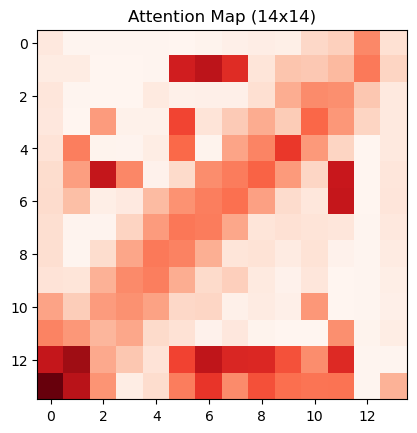

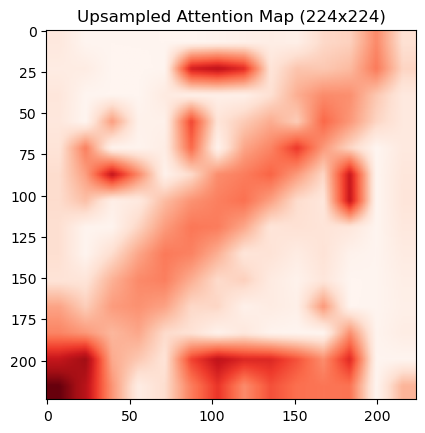

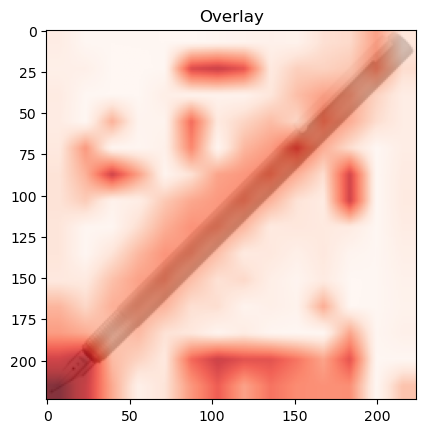

In [43]:
transformer_input = image_processor(images=image, return_tensors='pt')

transformer_output = image_transformer(**transformer_input, output_attentions=True)

final_layer_attention = transformer_output.attentions[-1]
print(f'final layer attention matrix: {final_layer_attention.shape}')

averaged_final_layer_attention = final_layer_attention.mean(dim=1)
print(f'averaged out final layer attention matrix: {averaged_final_layer_attention.shape}')

cls_token_vector = averaged_final_layer_attention[:, 0, :]
print(f'[CLS] token vector:  {cls_token_vector.shape}')

cls_token_vector = cls_token_vector[:, 1:]
reshaped_vector = cls_token_vector.reshape(1, 14, 14)

print(f'reshaped [CLS] vector: {reshaped_vector.shape}')

attention_map = reshaped_vector

upsample_input = attention_map.unsqueeze(1)
upsampled_attention_map = functional.interpolate(upsample_input, size=(224,224), mode='bilinear', align_corners=False)

attention_map = attention_map.detach().squeeze().cpu().numpy()
upsampled_attention_map = upsampled_attention_map.detach().squeeze().cpu().numpy()

plt.figure()
plt.imshow(attention_map, cmap='Reds')
plt.title('Attention Map (14x14)')

plt.figure()
plt.imshow(upsampled_attention_map, cmap='Reds')
plt.title('Upsampled Attention Map (224x224)')
plt.show()

plt.figure()
plt.imshow(image.resize((224,224)))
plt.imshow(upsampled_attention_map, alpha=0.8, cmap='Reds')
plt.title('Overlay')
plt.show()



# Task 2.4

### Loading models and data